<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

An ANOVA (Analysis of Variance) is a statistical formula used to compare the means of two or more groups to determine if at least one of them is significantly different from the others.

While a t-test is great for comparing two groups (like "Coffee Drinkers" vs. "Tea Drinkers"), ANOVA is your go-to when you have three or more groups (like "Coffee," "Tea," and "Energy Drinks") and you want to avoid the "family-wise error rate"—basically, the more t-tests you run, the higher the chance you'll find a "significant" result just by pure luck.

How It Works: The LogicInstead of looking at the means directly, ANOVA looks at variance. It breaks down the total variation in your data into two parts:Between-Group Variance: How much the means of the different groups differ from each other.Within-Group Variance: How much the individual scores inside each group differ from their own group mean (often called "noise" or "error").The F-statistic is then calculated:$$F = \frac{\text{Variance between groups}}{\text{Variance within groups}}$$High F-value: The groups are spread far apart compared to the noise within them, suggesting a significant difference.Low F-value: The differences between groups are small compared to the internal noise, suggesting any difference is likely due to chance.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)  # For reproducibility
data = {
    'Method_A': np.random.normal(loc=70, scale=10, size=30), # Mean=70
    'Method_B': np.random.normal(loc=72, scale=10, size=30), # Mean=72
    'Method_C': np.random.normal(loc=85, scale=10, size=30)  # Mean=85 (Clearly different)
}

# Convert to a DataFrame for easier handling
df = pd.DataFrame(data)

# 2. Perform One-Way ANOVA
# H0: All group means are equal
# H1: At least one group mean is different
f_stat, p_value = stats.f_oneway(df['Method_A'], df['Method_B'], df['Method_C'])

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically Significant (Reject H0)")
else:
    print("Result: Not Statistically Significant (Fail to reject H0)")

F-Statistic: 28.3049
P-Value: 0.0000
Result: Statistically Significant (Reject H0)


/tmp/ipykernel_17584/2785157634.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='Score', data=df_melted, palette="Set2")


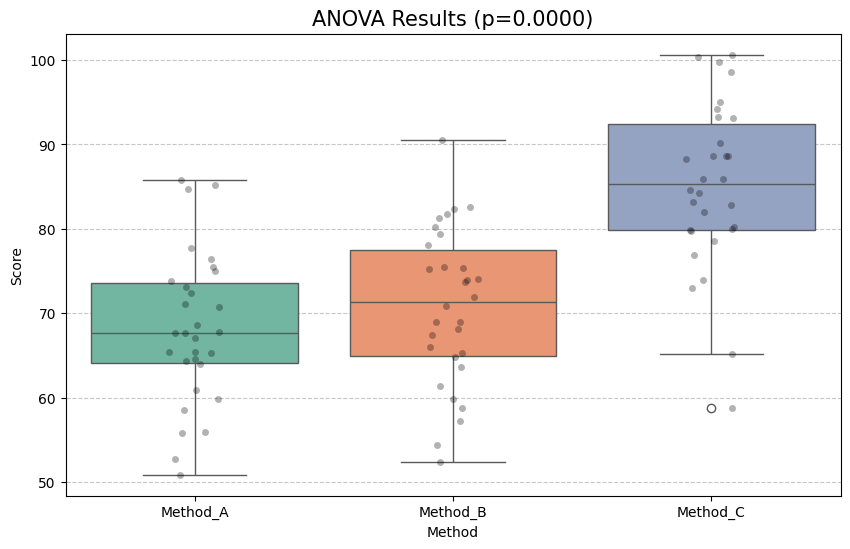

In [2]:
# Reshape data for plotting (Long-form)
df_melted = df.melt(var_name='Method', value_name='Score')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Method', y='Score', data=df_melted, palette="Set2")
sns.stripplot(x='Method', y='Score', data=df_melted, color="black", alpha=0.3) # Show raw data points

plt.title(f'ANOVA Results (p={p_value:.4f})', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [3]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Use the 'melted' dataframe from the previous step
tukey = pairwise_tukeyhsd(endog=df_melted['Score'],
                          groups=df_melted['Method'],
                          alpha=0.05)

print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
Method_A Method_B   2.6698 0.5179 -3.1286  8.4683  False
Method_A Method_C  17.0103    0.0 11.2119 22.8087   True
Method_B Method_C  14.3405    0.0  8.5421 20.1389   True
--------------------------------------------------------


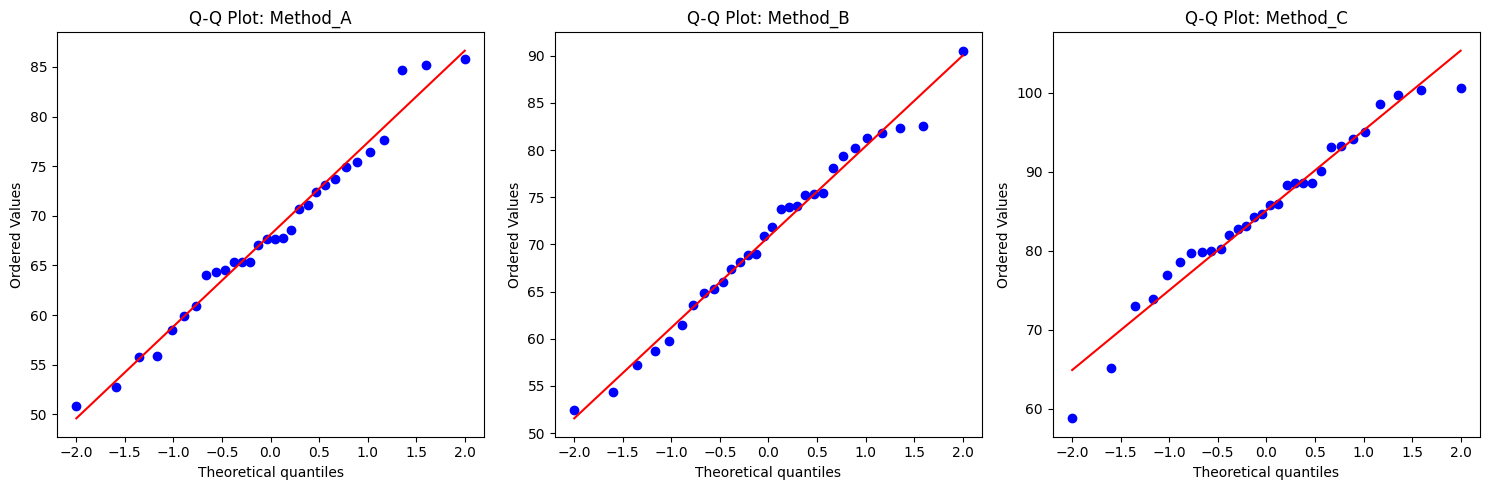

In [4]:
import scipy.stats as stats
import matplotlib.pyplot as plt

#usually check the residuals (errors), but checking the groups works too
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, method in enumerate(['Method_A', 'Method_B', 'Method_C']):
    stats.probplot(df[method], dist="norm", plot=ax[i])
    ax[i].set_title(f'Q-Q Plot: {method}')

plt.tight_layout()
plt.show()

In [5]:
for method in df.columns:
    stat, p = stats.shapiro(df[method])
    print(f'{method} Shapiro-Wilk p-value: {p:.4f}')

Method_A Shapiro-Wilk p-value: 0.6868
Method_B Shapiro-Wilk p-value: 0.9130
Method_C Shapiro-Wilk p-value: 0.3654


Final Conclusion: We performed a One-Way ANOVA to compare three learning methods. The test was statistically significant ($F=28.3, p<0.0001$). Post-hoc testing via Tukey HSD revealed that Method C significantly outperforms both Method A and Method B. All statistical assumptions, including normality (verified via Shapiro-Wilk and Q-Q plots), were satisfied.